# Golf Swing Analysis v2 — 24 Practice vs 24 Real Putts

8 features per second at 25Hz internal sampling.

In [1]:
import fitparse
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('agg')
import matplotlib.pyplot as plt
from IPython.display import Image, display
from scipy.signal import find_peaks

def load_fit(path):
    fitfile = fitparse.FitFile(path)
    records = []
    for record in fitfile.get_messages("record"):
        row = {}
        for field in record.fields:
            row[field.name] = field.value
        records.append(row)
    df = pd.DataFrame(records)
    df['elapsed'] = range(len(df))
    return df

def show_plot(fig, filename):
    fig.savefig(filename, dpi=150, bbox_inches='tight')
    plt.close(fig)
    display(Image(filename=filename))

practice = load_fit("24Practiceputts.fit")
real = load_fit("24realputts.fit")

features = ['peak_mag', 'min_mag', 'mean_mag', 'std_mag', 'max_jerk', 'peak_x', 'peak_y', 'peak_z']

# Drop first row (NaN from startup)
practice = practice.dropna(subset=['peak_mag']).reset_index(drop=True)
practice['elapsed'] = range(len(practice))
real = real.dropna(subset=['peak_mag']).reset_index(drop=True)
real['elapsed'] = range(len(real))

print(f"Practice: {len(practice)} seconds of data")
print(f"Real:     {len(real)} seconds of data")

Practice: 123 seconds of data
Real:     152 seconds of data


## Stroke Detection & Counting

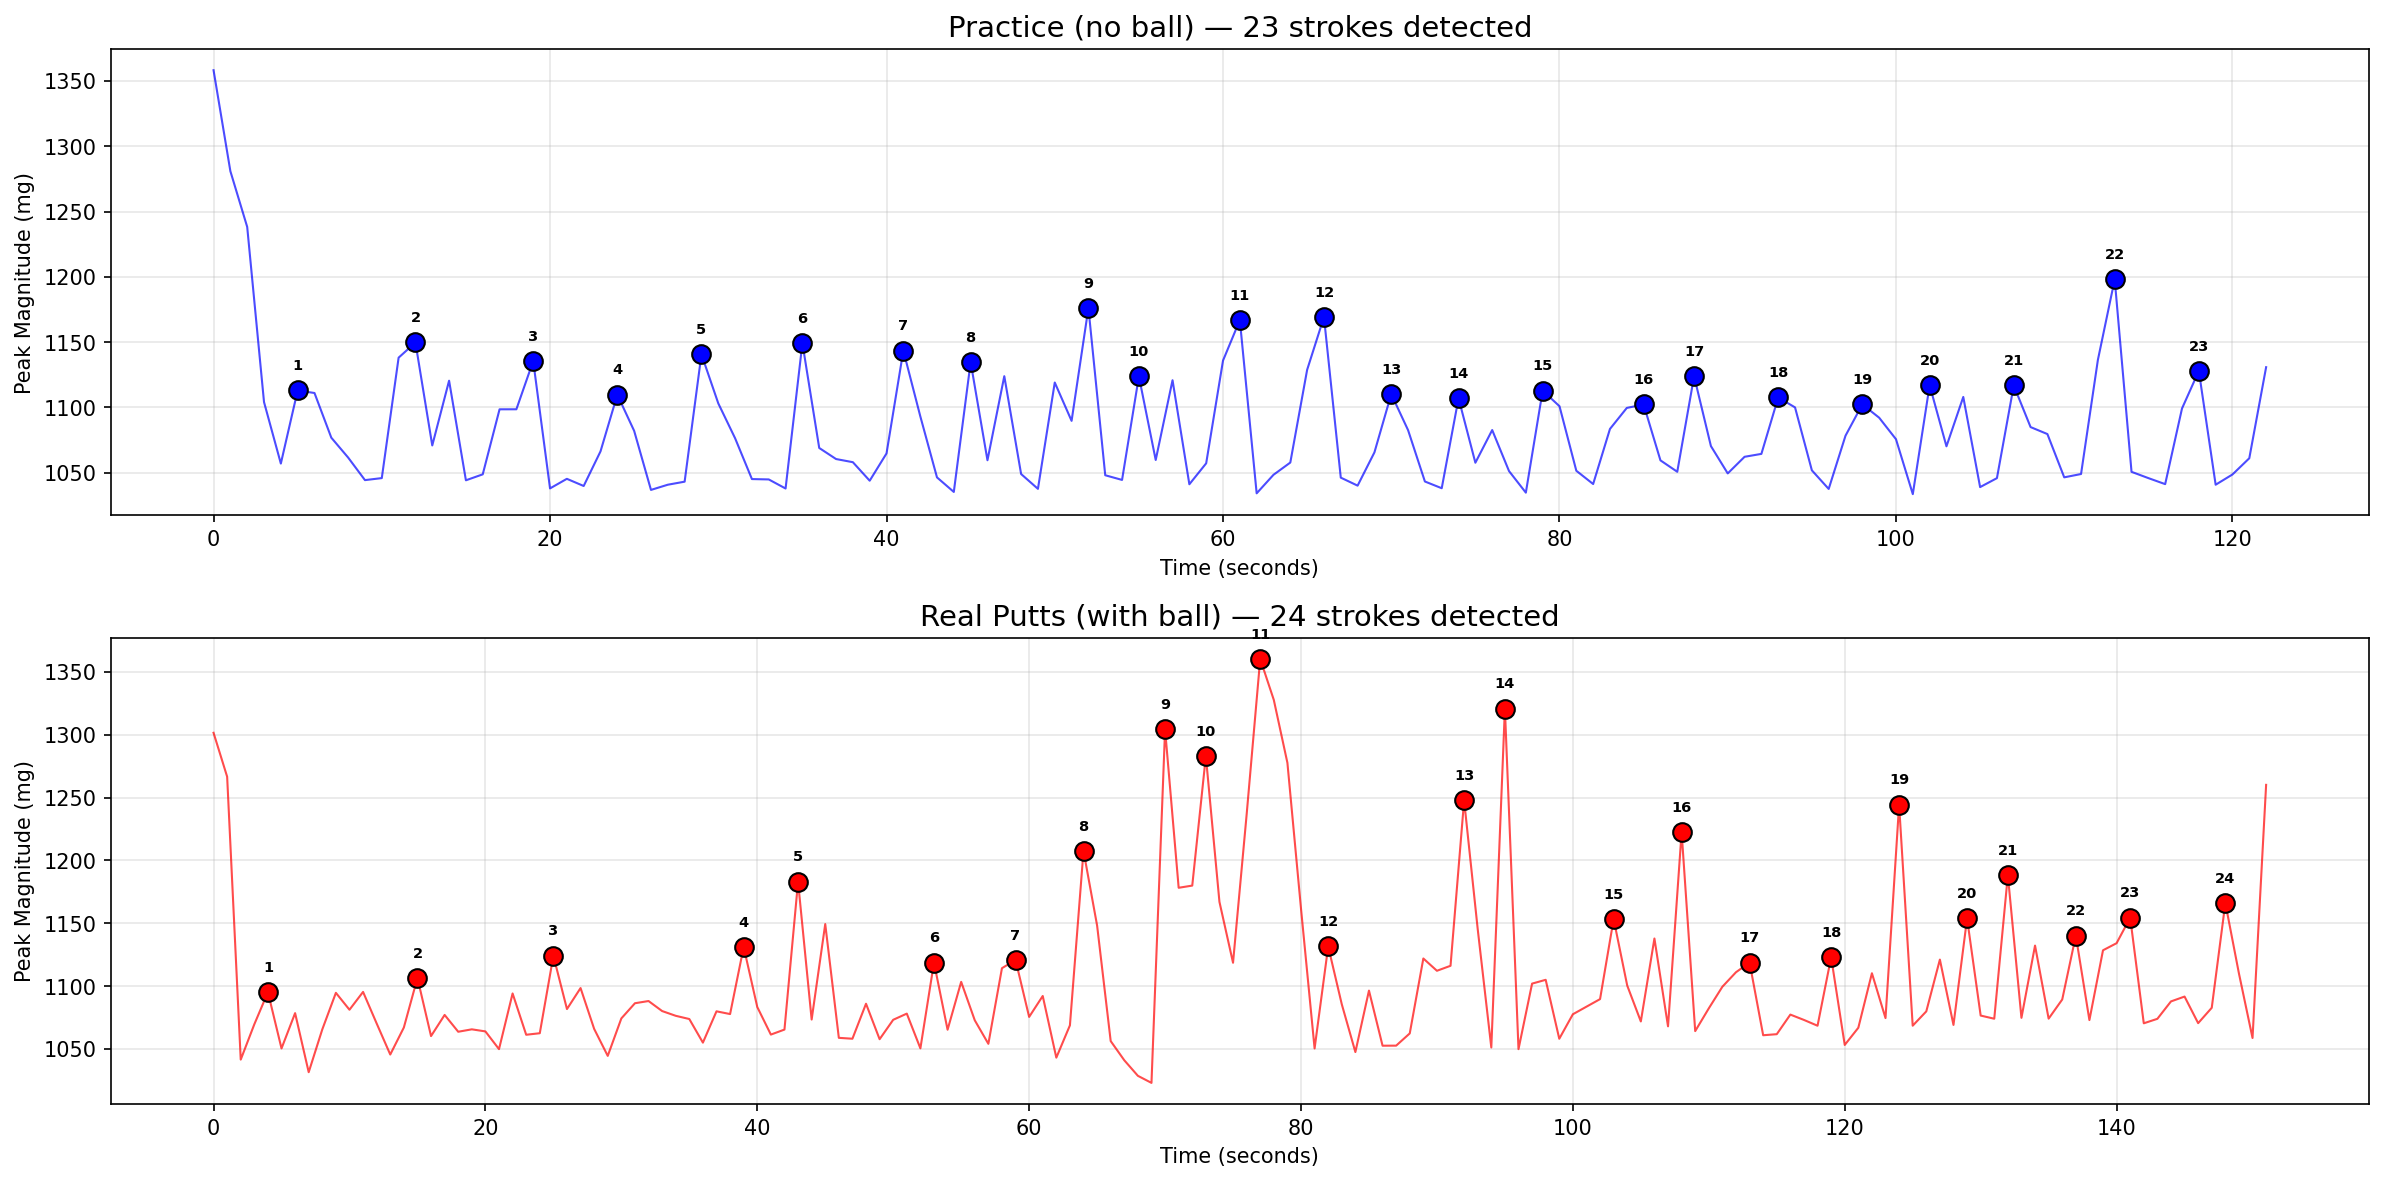

In [2]:
# Detect strokes using peak_mag spikes
fig, axes = plt.subplots(2, 1, figsize=(16, 8))

for i, (label, df, color) in enumerate([('Practice (no ball)', practice, 'blue'), ('Real Putts (with ball)', real, 'red')]):
    mag = df['peak_mag'].values
    elapsed = df['elapsed'].values
    peaks, _ = find_peaks(mag, distance=3, prominence=50)
    
    axes[i].plot(elapsed, mag, color=color, linewidth=1, alpha=0.7)
    axes[i].scatter(elapsed[peaks], mag[peaks], color=color, s=80, zorder=5, edgecolors='black', linewidth=1)
    
    for j, p in enumerate(peaks):
        axes[i].annotate(f'{j+1}', (elapsed[p], mag[p]), textcoords="offset points",
                        xytext=(0, 10), ha='center', fontsize=7, fontweight='bold')
    
    axes[i].set_title(f'{label} — {len(peaks)} strokes detected', fontsize=14)
    axes[i].set_ylabel('Peak Magnitude (mg)')
    axes[i].set_xlabel('Time (seconds)')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
show_plot(fig, 'v2_stroke_detection.png')

## New Features: Max Jerk & Std Magnitude (Impact Detection)

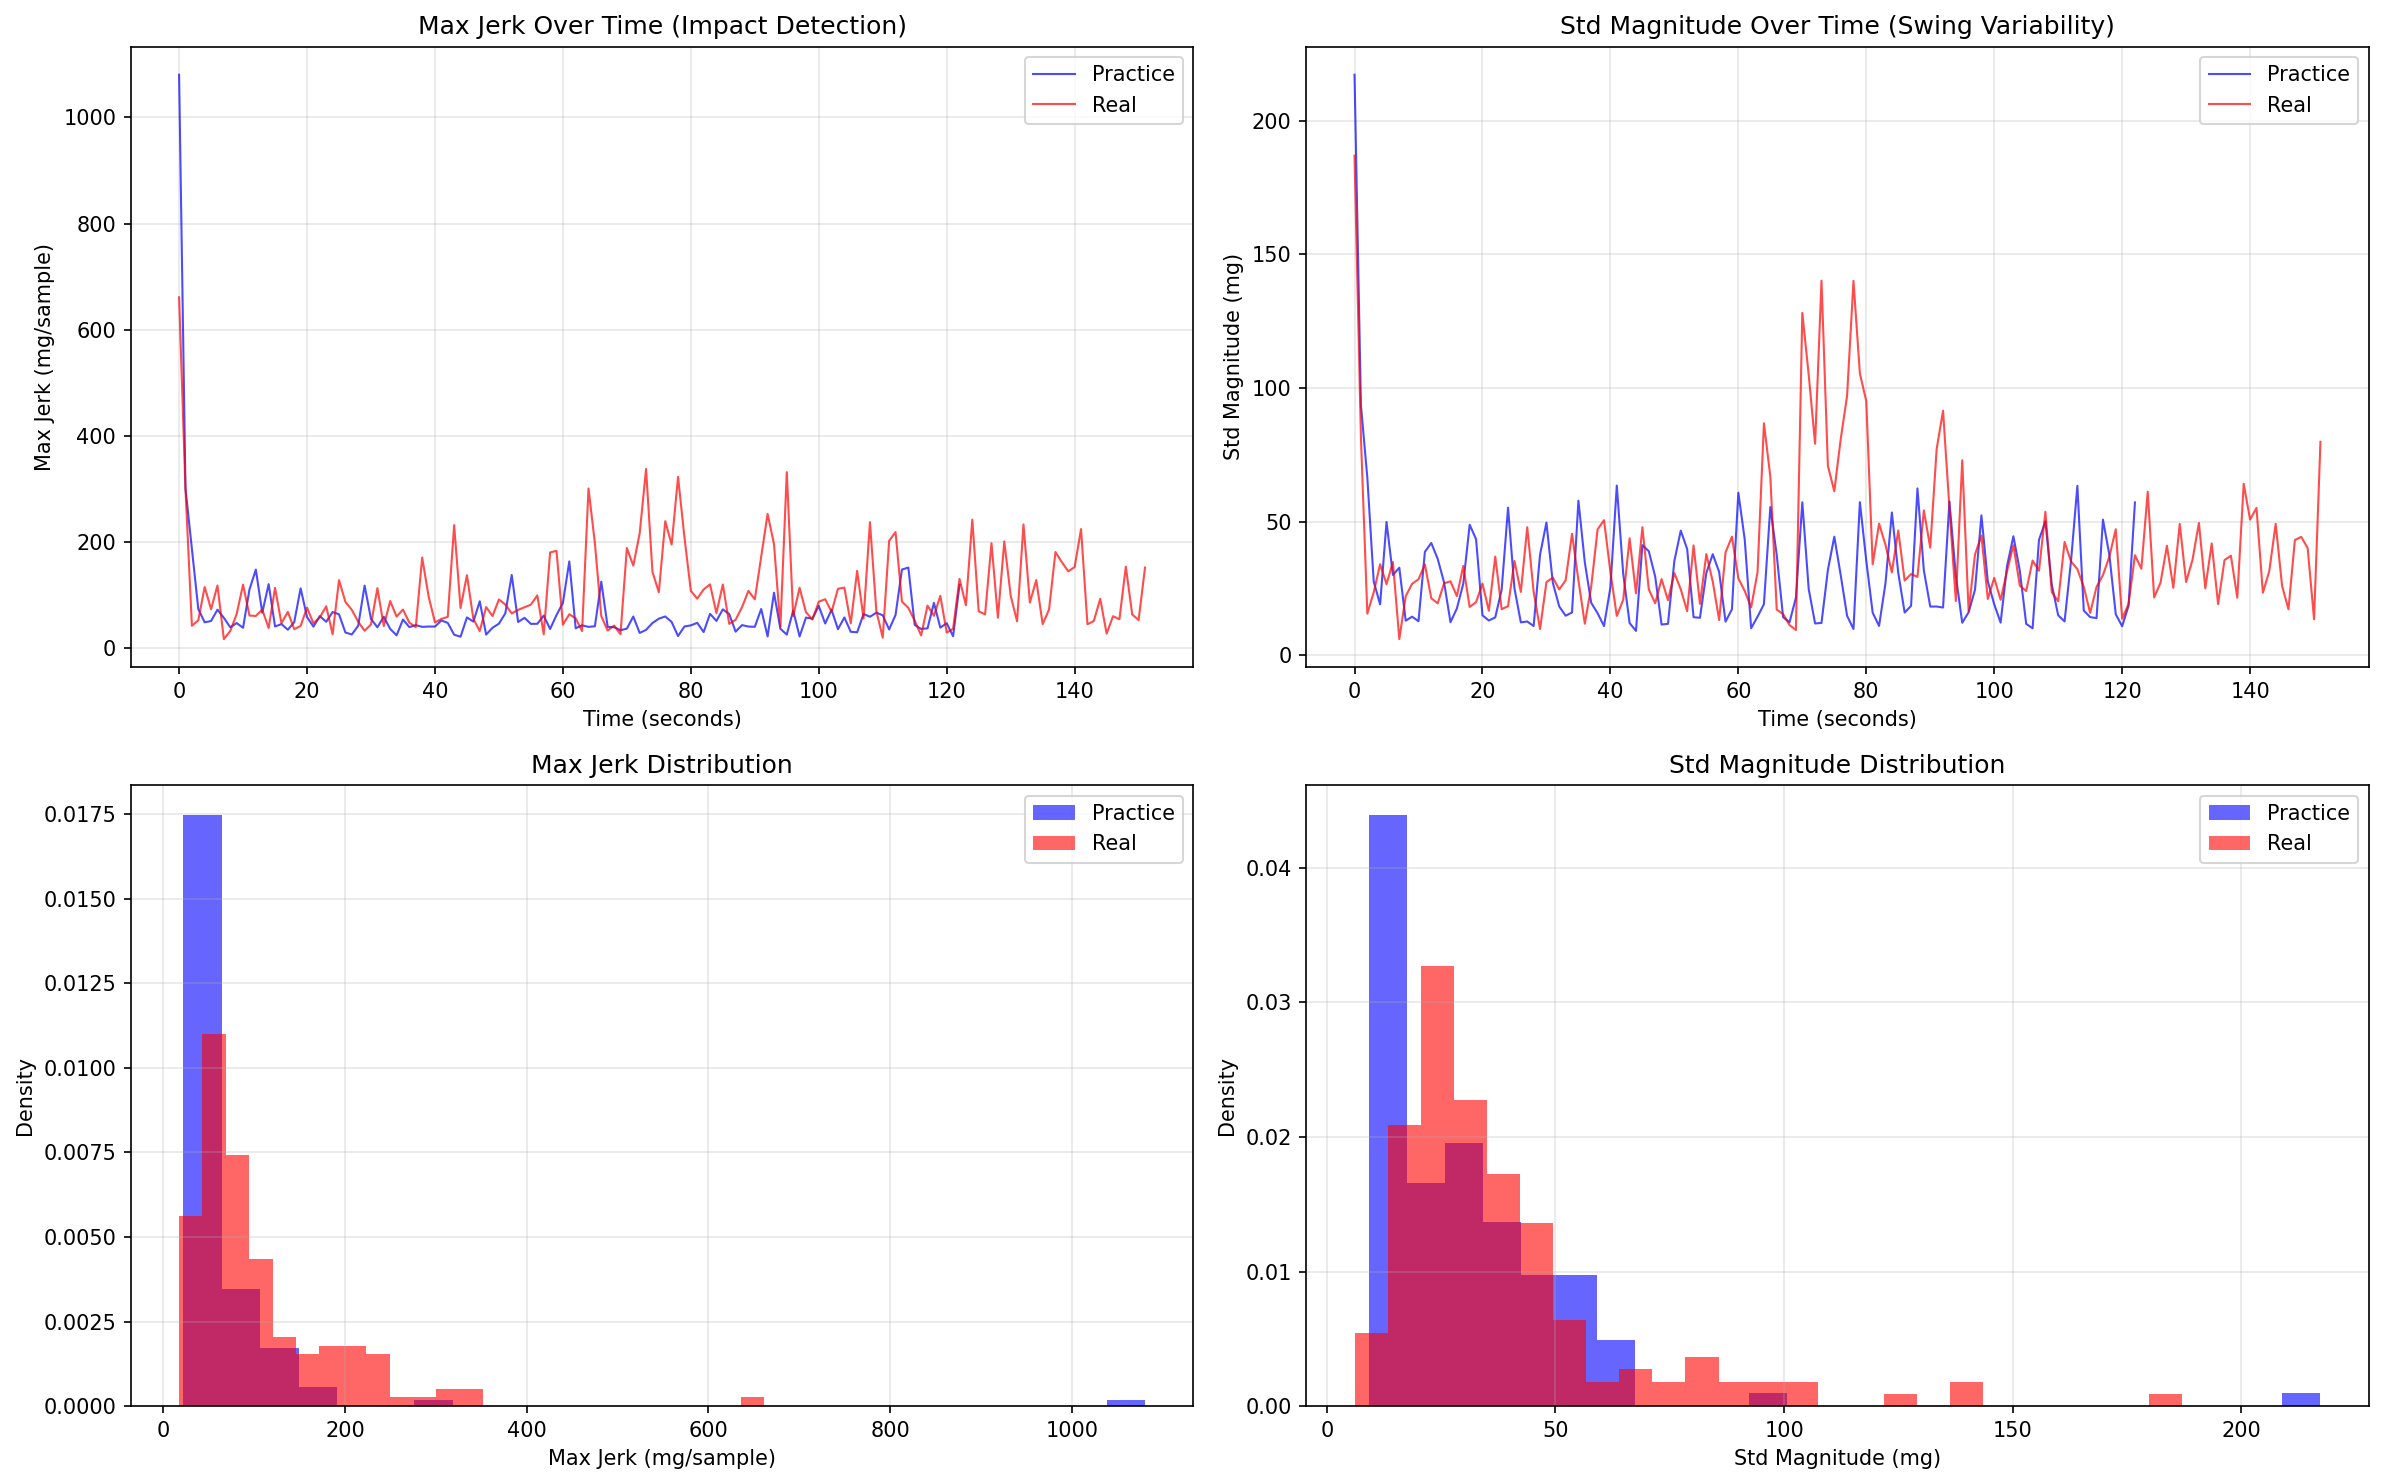

In [3]:
# Compare max_jerk and std_mag — these should show the biggest differences
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Max Jerk time series
axes[0][0].plot(practice['elapsed'], practice['max_jerk'], color='blue', linewidth=1, alpha=0.7, label='Practice')
axes[0][0].plot(real['elapsed'], real['max_jerk'], color='red', linewidth=1, alpha=0.7, label='Real')
axes[0][0].set_title('Max Jerk Over Time (Impact Detection)', fontsize=12)
axes[0][0].set_ylabel('Max Jerk (mg/sample)')
axes[0][0].set_xlabel('Time (seconds)')
axes[0][0].legend()
axes[0][0].grid(True, alpha=0.3)

# Std Mag time series
axes[0][1].plot(practice['elapsed'], practice['std_mag'], color='blue', linewidth=1, alpha=0.7, label='Practice')
axes[0][1].plot(real['elapsed'], real['std_mag'], color='red', linewidth=1, alpha=0.7, label='Real')
axes[0][1].set_title('Std Magnitude Over Time (Swing Variability)', fontsize=12)
axes[0][1].set_ylabel('Std Magnitude (mg)')
axes[0][1].set_xlabel('Time (seconds)')
axes[0][1].legend()
axes[0][1].grid(True, alpha=0.3)

# Max Jerk distribution
axes[1][0].hist(practice['max_jerk'].dropna(), bins=25, alpha=0.6, color='blue', label='Practice', density=True)
axes[1][0].hist(real['max_jerk'].dropna(), bins=25, alpha=0.6, color='red', label='Real', density=True)
axes[1][0].set_title('Max Jerk Distribution', fontsize=12)
axes[1][0].set_xlabel('Max Jerk (mg/sample)')
axes[1][0].set_ylabel('Density')
axes[1][0].legend()
axes[1][0].grid(True, alpha=0.3)

# Std Mag distribution
axes[1][1].hist(practice['std_mag'].dropna(), bins=25, alpha=0.6, color='blue', label='Practice', density=True)
axes[1][1].hist(real['std_mag'].dropna(), bins=25, alpha=0.6, color='red', label='Real', density=True)
axes[1][1].set_title('Std Magnitude Distribution', fontsize=12)
axes[1][1].set_xlabel('Std Magnitude (mg)')
axes[1][1].set_ylabel('Density')
axes[1][1].legend()
axes[1][1].grid(True, alpha=0.3)

plt.tight_layout()
show_plot(fig, 'v2_jerk_std.png')

## Stroke-Level Feature Comparison (at detected peaks only)

Practice strokes: 23
Real strokes: 24


/tmp/ipykernel_3336/2778922642.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([p_strokes[feat].values, r_strokes[feat].values],
/tmp/ipykernel_3336/2778922642.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([p_strokes[feat].values, r_strokes[feat].values],
/tmp/ipykernel_3336/2778922642.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([p_strokes[feat].values, r_strokes[feat].values],
/tmp/ipykernel_3336/2778922642.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the ol

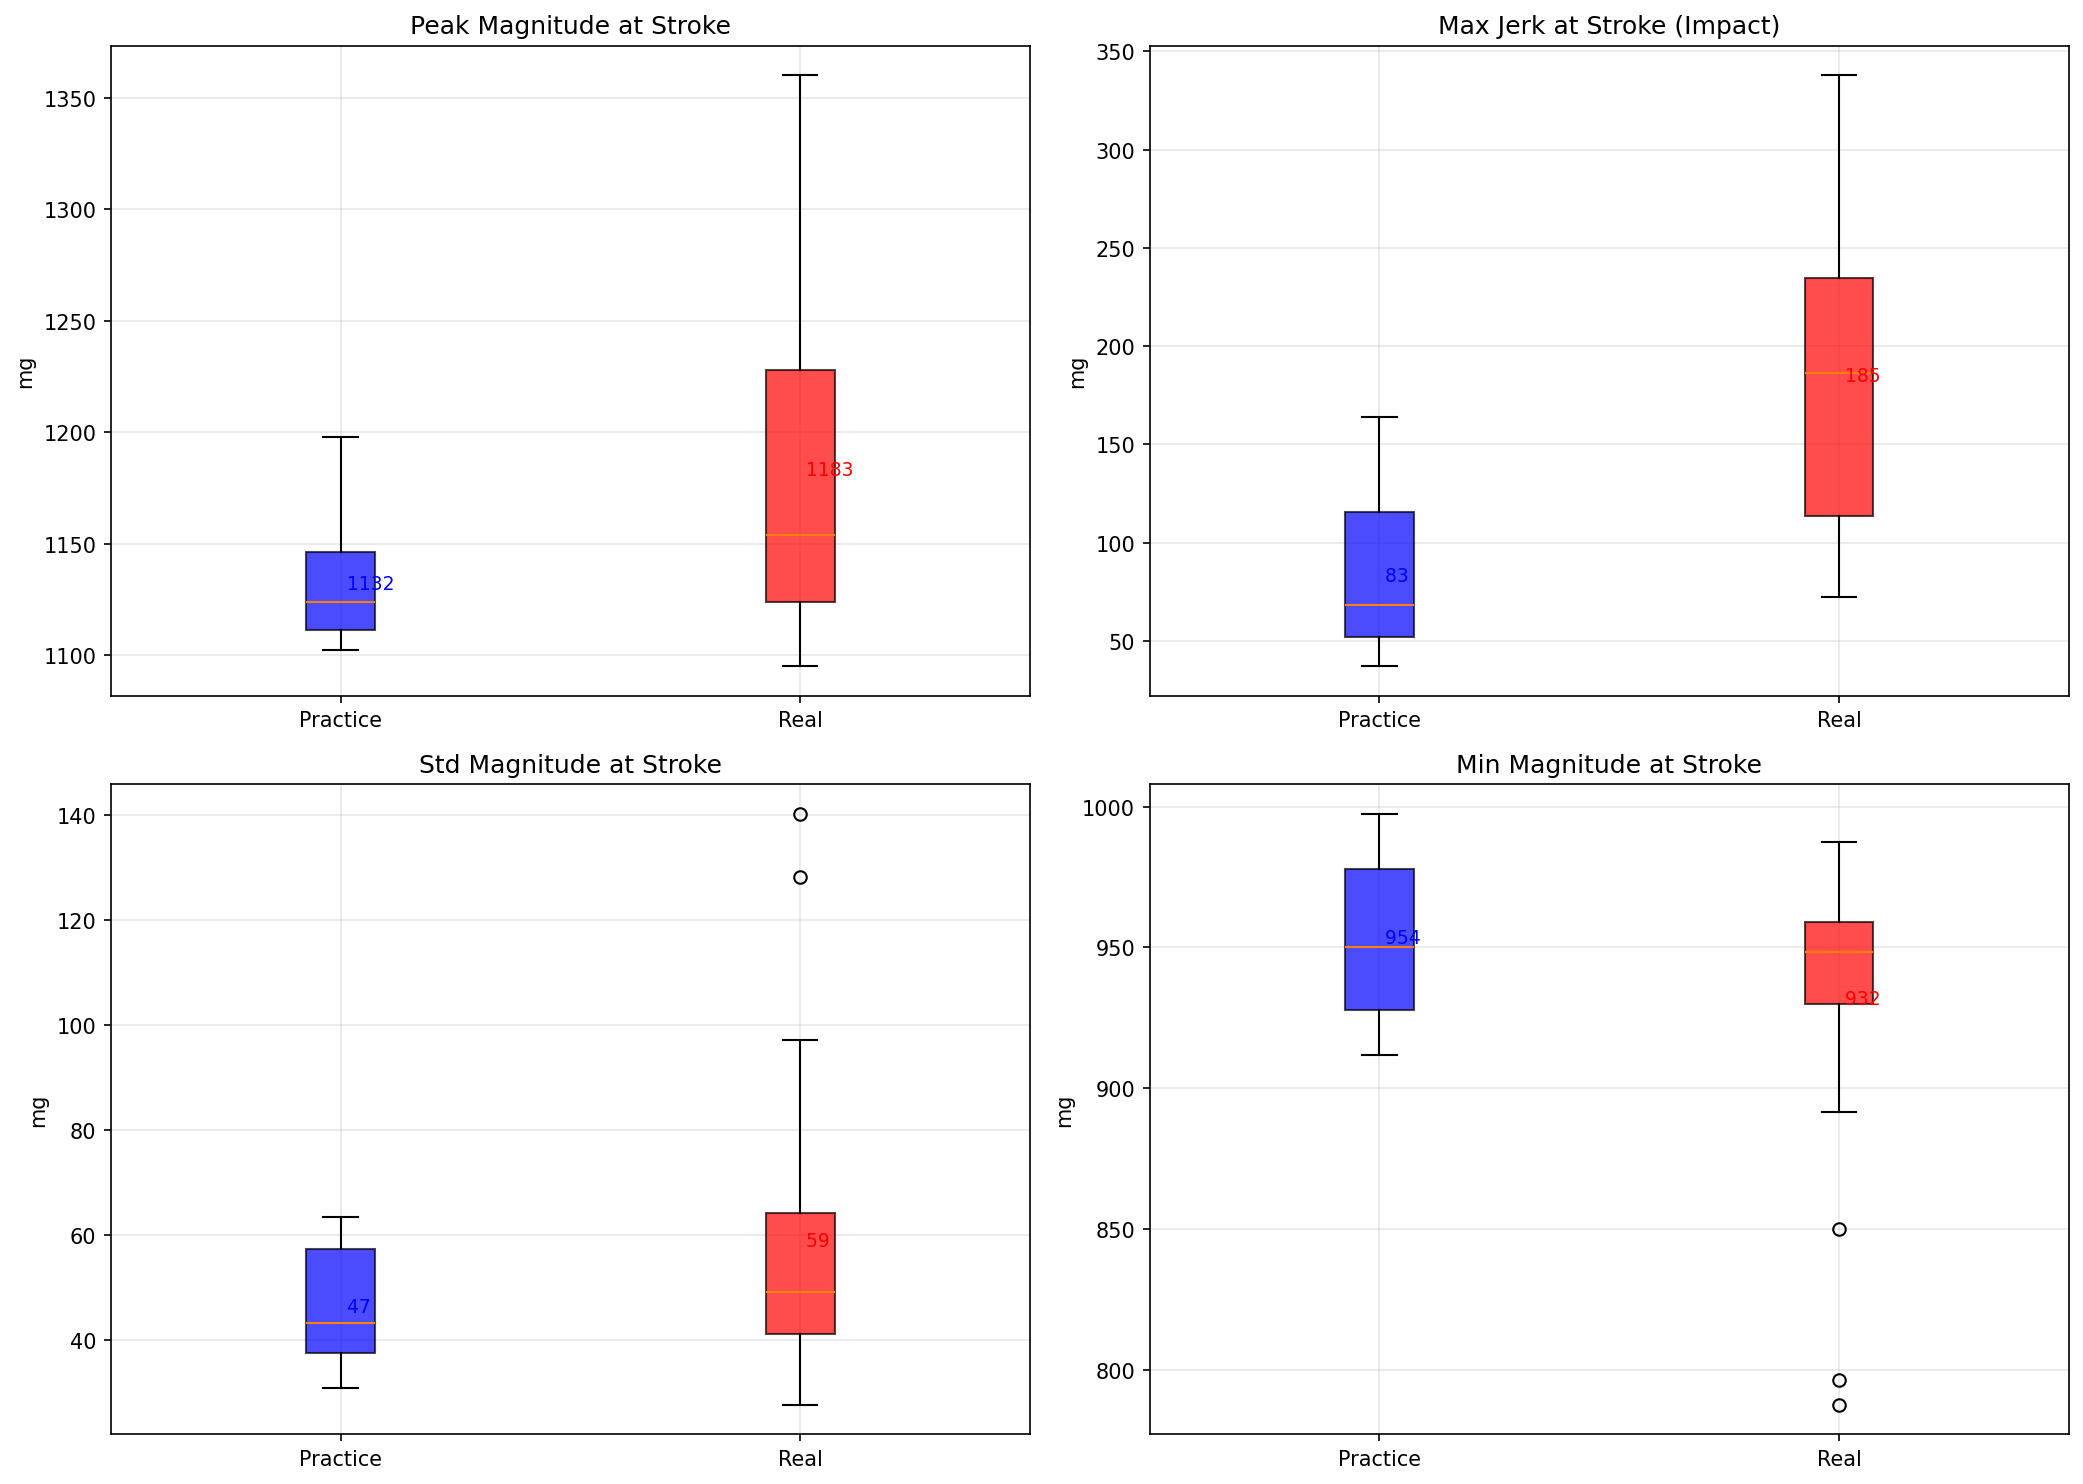

In [4]:
# Extract features at detected stroke times
p_peaks, _ = find_peaks(practice['peak_mag'].values, distance=3, prominence=50)
r_peaks, _ = find_peaks(real['peak_mag'].values, distance=3, prominence=50)

p_strokes = practice.iloc[p_peaks][features].copy()
p_strokes['type'] = 'practice'
r_strokes = real.iloc[r_peaks][features].copy()
r_strokes['type'] = 'real'

print(f"Practice strokes: {len(p_strokes)}")
print(f"Real strokes: {len(r_strokes)}")

# Compare key features at stroke moments
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

compare_features = ['peak_mag', 'max_jerk', 'std_mag', 'min_mag']
titles = ['Peak Magnitude at Stroke', 'Max Jerk at Stroke (Impact)', 'Std Magnitude at Stroke', 'Min Magnitude at Stroke']

for i, (feat, title) in enumerate(zip(compare_features, titles)):
    ax = axes[i // 2][i % 2]
    bp = ax.boxplot([p_strokes[feat].values, r_strokes[feat].values],
                    labels=['Practice', 'Real'], patch_artist=True,
                    boxprops=dict(alpha=0.7))
    bp['boxes'][0].set_facecolor('blue')
    bp['boxes'][1].set_facecolor('red')
    ax.set_title(title, fontsize=12)
    ax.set_ylabel('mg')
    ax.grid(True, alpha=0.3)
    
    # Add means as text
    p_mean = p_strokes[feat].mean()
    r_mean = r_strokes[feat].mean()
    ax.text(1, p_mean, f' {p_mean:.0f}', va='center', fontsize=9, color='blue')
    ax.text(2, r_mean, f' {r_mean:.0f}', va='center', fontsize=9, color='red')

plt.tight_layout()
show_plot(fig, 'v2_stroke_features.png')

## Statistical Summary & Feature Importance

FEATURE COMPARISON AT DETECTED STROKES

peak_mag:
  Practice: mean=1132.0  std=26.2
  Real:     mean=1183.2  std=74.6
  Diff:     +4.5%

min_mag:
  Practice: mean=953.6  std=28.0
  Real:     mean=932.0  std=51.5
  Diff:     -2.3%

mean_mag:
  Practice: mean=1027.9  std=14.3
  Real:     mean=1027.0  std=12.6
  Diff:     -0.1%

std_mag:
  Practice: mean=46.5  std=11.0
  Real:     mean=58.9  std=29.5
  Diff:     +26.7%

max_jerk:
  Practice: mean=83.4  std=40.0
  Real:     mean=185.0  std=77.3
  Diff:     +121.8%

peak_x:
  Practice: mean=857.3  std=23.4
  Real:     mean=919.1  std=101.3
  Diff:     +7.2%

peak_y:
  Practice: mean=174.1  std=30.2
  Real:     mean=319.1  std=182.8
  Diff:     +83.3%

peak_z:
  Practice: mean=771.9  std=36.8
  Real:     mean=790.2  std=78.6
  Diff:     +2.4%


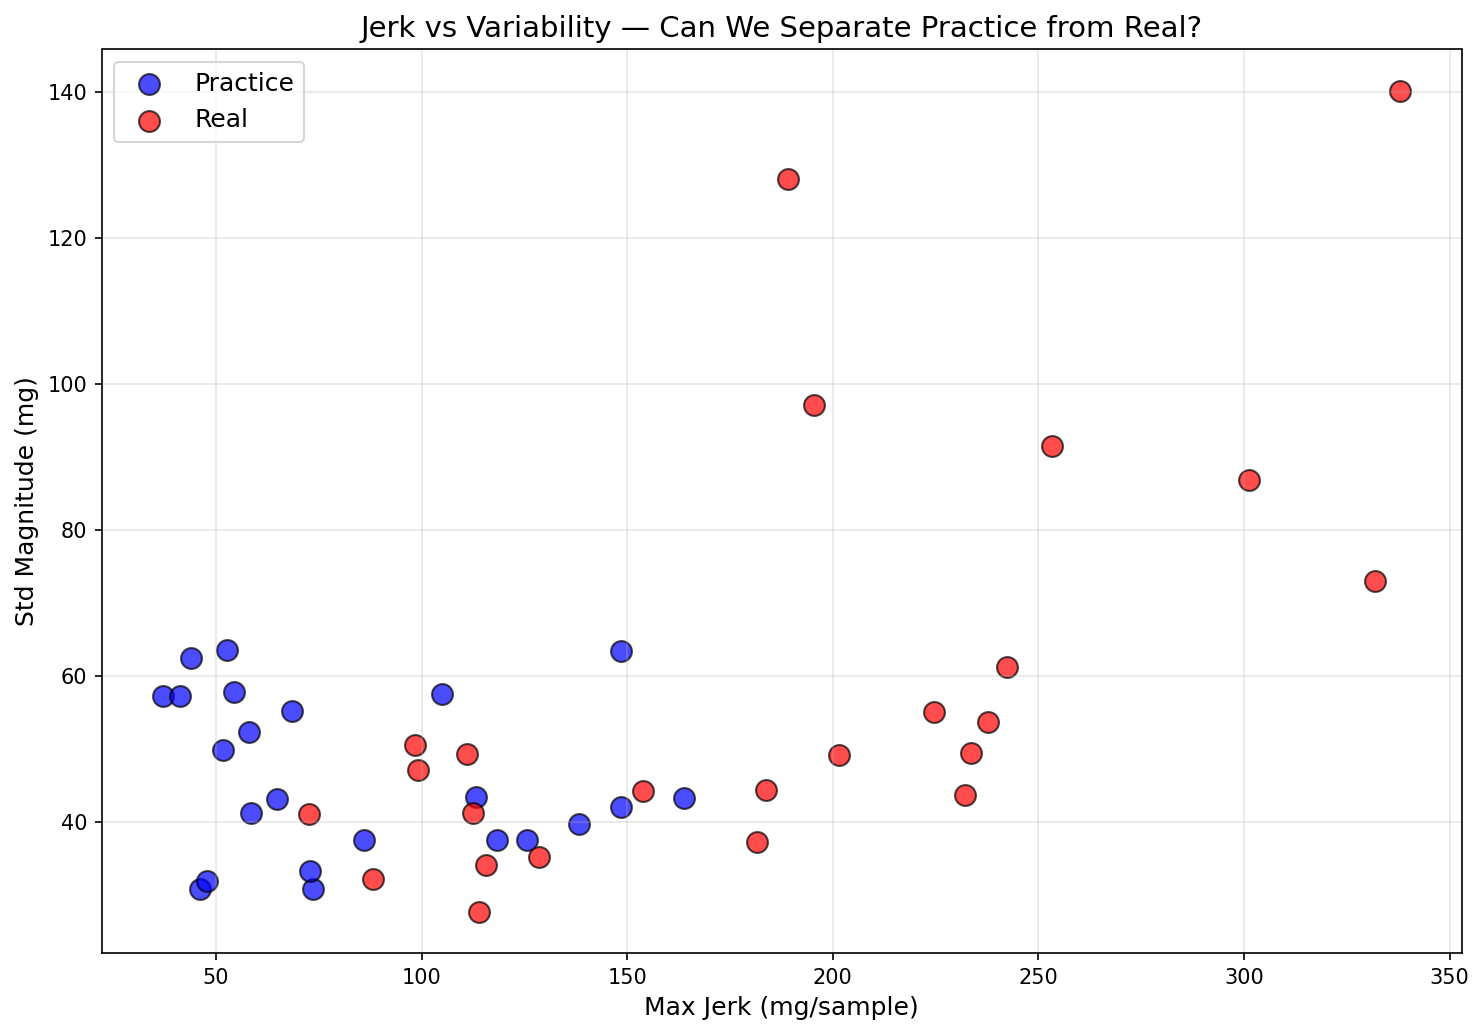

In [5]:
# Statistical comparison of all features at stroke moments
print("=" * 70)
print("FEATURE COMPARISON AT DETECTED STROKES")
print("=" * 70)

for feat in features:
    p_vals = p_strokes[feat].dropna()
    r_vals = r_strokes[feat].dropna()
    diff_pct = (r_vals.mean() - p_vals.mean()) / p_vals.mean() * 100
    print(f"\n{feat}:")
    print(f"  Practice: mean={p_vals.mean():.1f}  std={p_vals.std():.1f}")
    print(f"  Real:     mean={r_vals.mean():.1f}  std={r_vals.std():.1f}")
    print(f"  Diff:     {diff_pct:+.1f}%")

# Scatter plot: jerk vs std_mag colored by type
fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(p_strokes['max_jerk'], p_strokes['std_mag'], color='blue', s=100, alpha=0.7, label='Practice', edgecolors='black')
ax.scatter(r_strokes['max_jerk'], r_strokes['std_mag'], color='red', s=100, alpha=0.7, label='Real', edgecolors='black')
ax.set_xlabel('Max Jerk (mg/sample)', fontsize=12)
ax.set_ylabel('Std Magnitude (mg)', fontsize=12)
ax.set_title('Jerk vs Variability — Can We Separate Practice from Real?', fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
show_plot(fig, 'v2_scatter.png')

## ML Classification: Practice vs Real Putts

Using a Random Forest classifier with Leave-One-Out cross-validation (since we have limited data).

In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Combine stroke-level data
all_strokes = pd.concat([p_strokes, r_strokes], ignore_index=True)
X = all_strokes[features].values
y = (all_strokes['type'] == 'real').astype(int).values  # 0=practice, 1=real

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Leave-One-Out CV (best for small datasets — trains on N-1, tests on 1, repeats N times)
loo = LeaveOneOut()
clf = RandomForestClassifier(n_estimators=100, random_state=42)
y_pred = cross_val_predict(clf, X_scaled, y, cv=loo)

acc = accuracy_score(y, y_pred)
print(f"Leave-One-Out Accuracy: {acc:.1%} ({sum(y_pred == y)}/{len(y)} correct)")
print(f"\nClassification Report:")
print(classification_report(y, y_pred, target_names=['Practice', 'Real']))

print("Confusion Matrix:")
cm = confusion_matrix(y, y_pred)
print(f"                Predicted")
print(f"              Prac  Real")
print(f"  Actual Prac  {cm[0][0]:3d}   {cm[0][1]:3d}")
print(f"  Actual Real  {cm[1][0]:3d}   {cm[1][1]:3d}")

Leave-One-Out Accuracy: 91.5% (43/47 correct)

Classification Report:
              precision    recall  f1-score   support

    Practice       0.91      0.91      0.91        23
        Real       0.92      0.92      0.92        24

    accuracy                           0.91        47
   macro avg       0.91      0.91      0.91        47
weighted avg       0.91      0.91      0.91        47

Confusion Matrix:
                Predicted
              Prac  Real
  Actual Prac   21     2
  Actual Real    2    22


## Feature Importance — Which Sensor Features Matter Most?

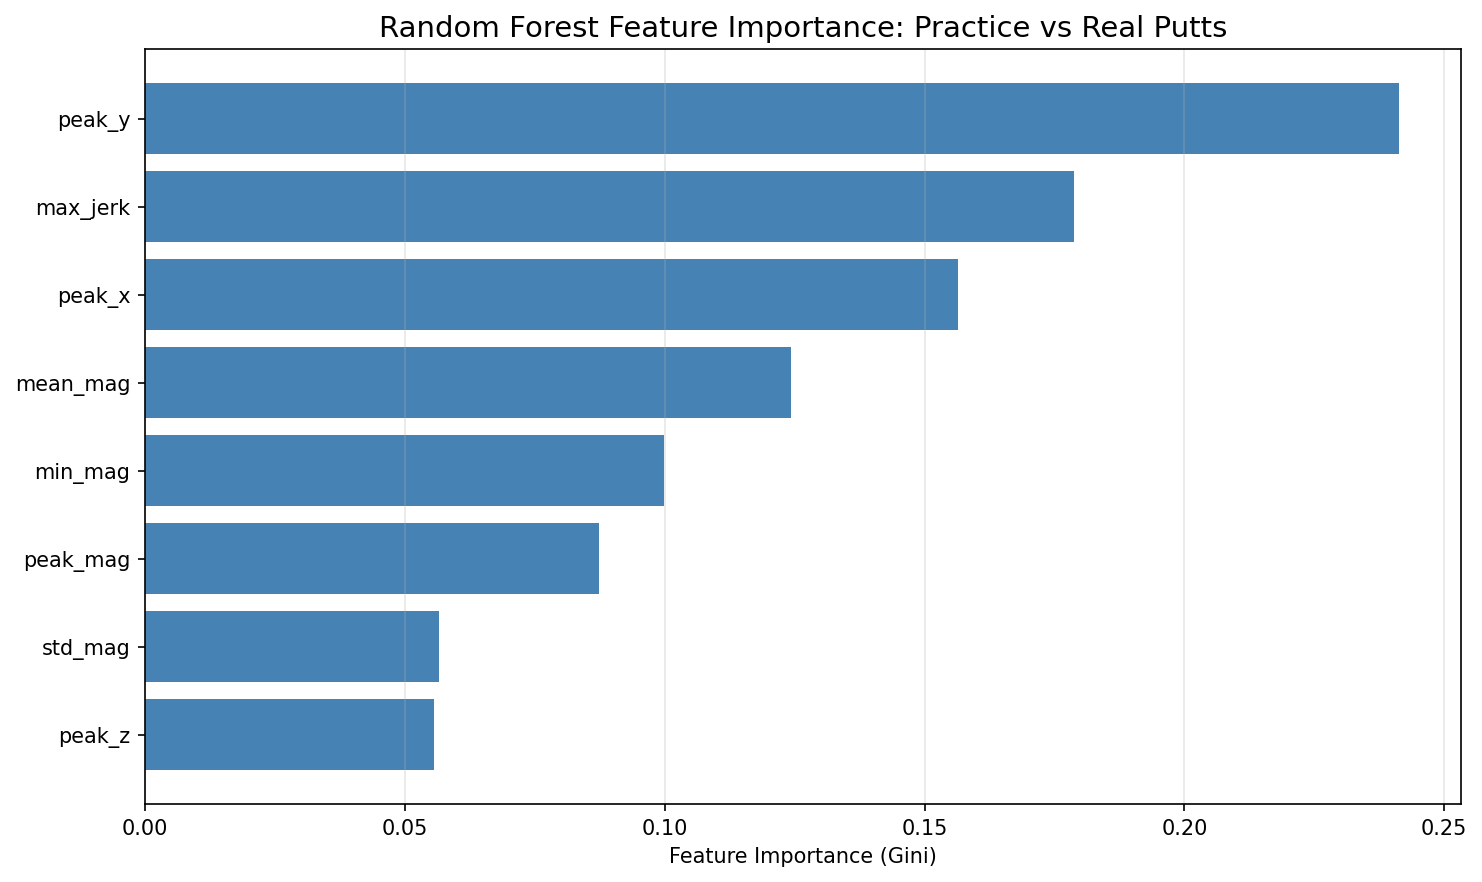

In [7]:
# Train on full data to get feature importances
clf_full = RandomForestClassifier(n_estimators=100, random_state=42)
clf_full.fit(X_scaled, y)

importances = clf_full.feature_importances_
sorted_idx = np.argsort(importances)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(range(len(features)), importances[sorted_idx], color='steelblue')
ax.set_yticks(range(len(features)))
ax.set_yticklabels([features[i] for i in sorted_idx])
ax.set_xlabel('Feature Importance (Gini)')
ax.set_title('Random Forest Feature Importance: Practice vs Real Putts', fontsize=14)
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
show_plot(fig, 'v2_feature_importance.png')

## Decision Boundary Visualization (Top 2 Features)

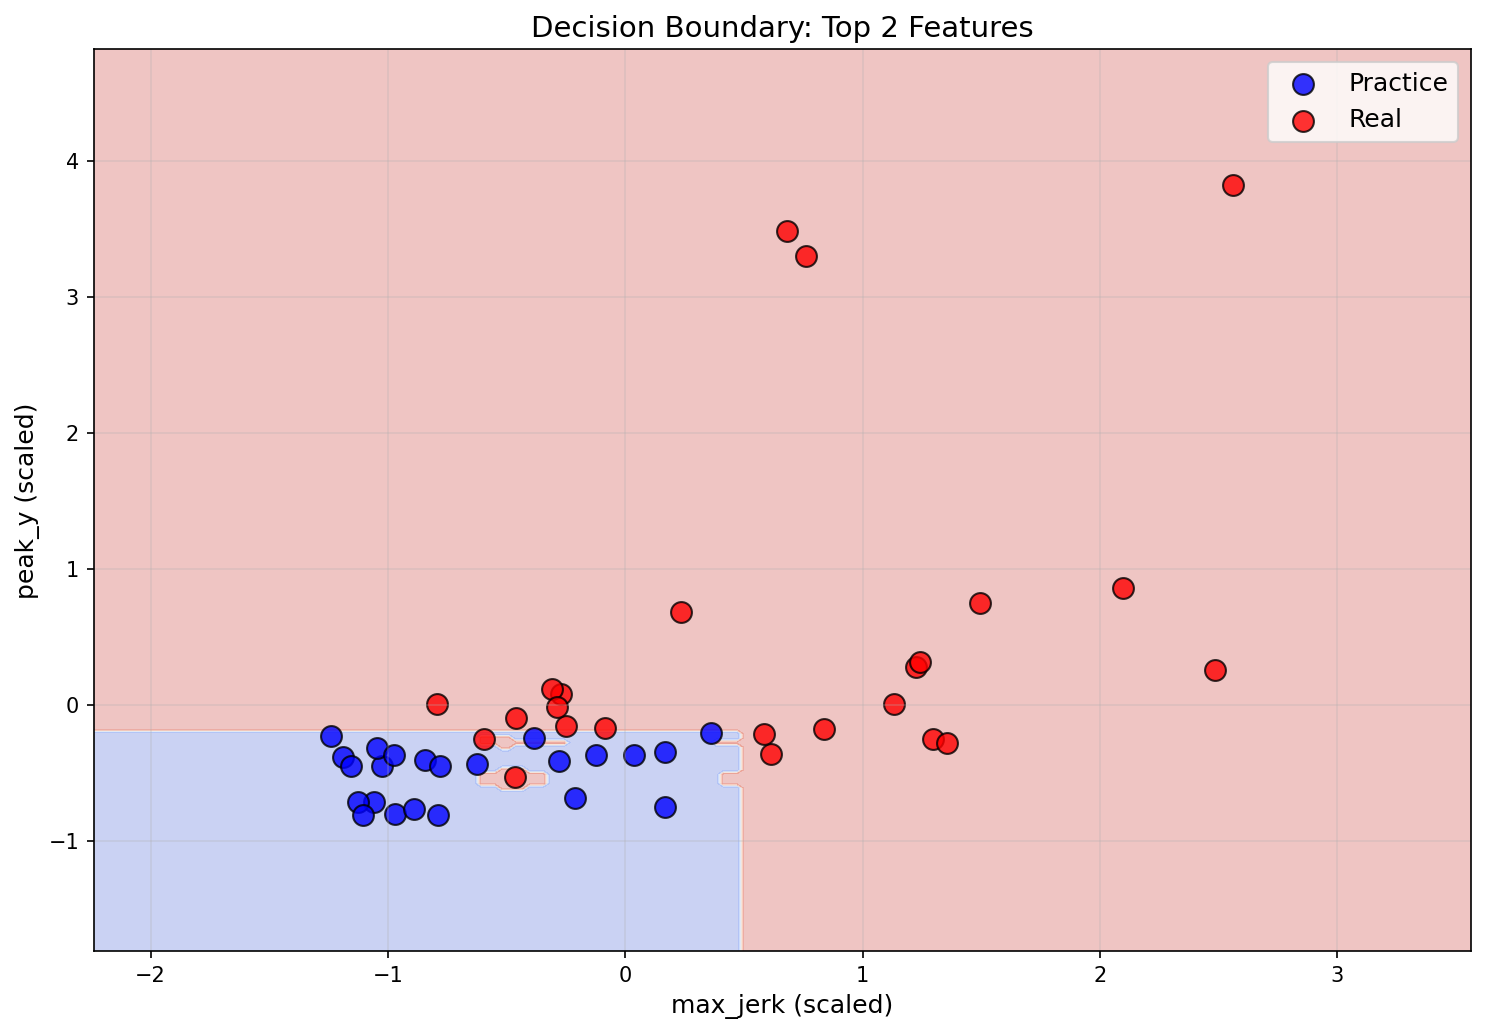


Accuracy with just max_jerk + peak_y: 89.4%


In [8]:
# Train a classifier on just the top 2 features so we can visualize the decision boundary
top2_idx = sorted_idx[-2:]
top2_names = [features[i] for i in top2_idx]
X2 = X_scaled[:, top2_idx]

clf2 = RandomForestClassifier(n_estimators=100, random_state=42)
clf2.fit(X2, y)

# Create mesh grid for decision boundary
x_min, x_max = X2[:, 0].min() - 1, X2[:, 0].max() + 1
y_min, y_max = X2[:, 1].min() - 1, X2[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
Z = clf2.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(10, 7))
ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
ax.scatter(X2[y==0, 0], X2[y==0, 1], color='blue', s=100, alpha=0.8, label='Practice', edgecolors='black')
ax.scatter(X2[y==1, 0], X2[y==1, 1], color='red', s=100, alpha=0.8, label='Real', edgecolors='black')
ax.set_xlabel(f'{top2_names[0]} (scaled)', fontsize=12)
ax.set_ylabel(f'{top2_names[1]} (scaled)', fontsize=12)
ax.set_title('Decision Boundary: Top 2 Features', fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
show_plot(fig, 'v2_decision_boundary.png')

# Accuracy with just top 2 features
y_pred_2 = cross_val_predict(clf2, X2, y, cv=loo)
print(f"\nAccuracy with just {top2_names[0]} + {top2_names[1]}: {accuracy_score(y, y_pred_2):.1%}")